# HA2: BM25 ranking & оценка результатов поиска


### Зависимости 

In [ ]:
!pip install -q pandas numpy matplotlib scikit-learn rank-bm25 ir-measures ir_datasets nltk spacy tqdm datasets
!python -m spacy download en_core_web_sm

In [5]:
import os, re, json, math, time, random, gzip, pickle
from pathlib import Path
from collections import Counter, defaultdict
from ir_measures import read_trec_qrels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from math import log

from nltk.stem import PorterStemmer
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from rank_bm25 import BM25Okapi

import ir_measures
from ir_measures import P, MAP, nDCG, read_trec_run, iter_calc
from scipy.stats import spearmanr, wilcoxon

from datasets import load_dataset

RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

### Загрузка WikIR en1k через `ir_datasets`

**Форматы TREC**:
- `qrels`: `qid 0 docid relevance`
- `run`:   `qid Q0 docid rank score tag`

In [3]:
def create_qrels_dict(qrels_list):
    qrels = defaultdict(dict)
    for q in qrels_list:
        qrels[str(q.query_id)][str(q.doc_id)] = int(q.relevance)
    return dict(qrels)

test_path = '/kaggle/input/datasets/hemulitch/wikir1en/wikIR1k/test'
validation_path = '/kaggle/input/datasets/hemulitch/wikir1en/wikIR1k/validation'
path = '/kaggle/input/datasets/hemulitch/wikir1en/wikIR1k'

docs_df = pd.read_csv(f'{path}/documents.csv').rename({'id_right':'doc_id', 'text_right': 'text'}, axis=1)
test_q_df = pd.read_csv(f'{test_path}/queries.csv').rename({'id_left':'doc_id', 'text_left': 'text'}, axis=1)
val_q_df = pd.read_csv(f'{validation_path}/queries.csv').rename({'id_left':'doc_id', 'text_left': 'text'}, axis=1)

test_qrels_list = list(read_trec_qrels(f'{test_path}/qrels'))
val_qrels_list = list(read_trec_qrels(f'{validation_path}/qrels'))

test_qrels = create_qrels_dict(test_qrels_list)
val_qrels = create_qrels_dict(val_qrels_list)

In [4]:
print(f'Документов: {len(docs_df):,}')
print(f'Test queries: {len(test_q_df)}, qrels keys: {len(test_qrels)}')
print(f'Val queries:  {len(val_q_df)},  qrels keys: {len(val_qrels)}')

Документов: 369,721
Test queries: 100, qrels keys: 100
Val queries:  100,  qrels keys: 100


---
## 1. Базовая статистика по тестовым запросам

In [5]:
def tok(s):
    return [t for t in s.split() if any(c.isalnum() for c in t)]

test_q_lens = test_q_df['text'].astype(str).map(lambda s: len(tok(s)))

# Распределение по уровням релевантности в WikIR qrels:
#   rel=2: source article (та же статья, из которой взят запрос — её остаток)
#   rel=1: статьи, на которые ссылается первое предложение source article
#   rel=0: НЕ записывается в qrels (open-world assumption);
#          все документы, отсутствующие в qrels, трактуются метриками как non-relevant
rel_levels = Counter()
for qid, d in test_qrels.items():
    for doc, r in d.items():
        rel_levels[r] += 1

rel_per_q = pd.Series({qid: sum(1 for r in d.values() if r > 0) 
                       for qid, d in test_qrels.items()})
rel_per_q_source = pd.Series({qid: sum(1 for r in d.values() if r >= 2) 
                              for qid, d in test_qrels.items()})

stats = {
    '# queries': len(test_q_df),
    'avg query length (tokens)': round(test_q_lens.mean(), 2),
    'median query length': int(test_q_lens.median()),
    'min query length': int(test_q_lens.min()),
    'max query length': int(test_q_lens.max()),
    'avg # judged (rel>=1) per query': round(rel_per_q.mean(), 1),
    'min # judged (rel>=1) per query':       int(rel_per_q.min()),
    'max # judged (rel>=1) per query':       int(rel_per_q.max()),
    'avg # source article (rel=2) per query': round(rel_per_q_source.mean(), 1),
    'relevance levels distribution': dict(rel_levels),
}
display(pd.Series(stats).to_frame('value'))

,value
# queries,100
avg query length (tokens),2.07
median query length,2
min query length,1
max query length,9
avg # judged (rel>=1) per query,44.4
min # judged (rel>=1) per query,6
max # judged (rel>=1) per query,2759
avg # source article (rel=2) per query,1.0
relevance levels distribution,"{2: 100, 1: 4335}"


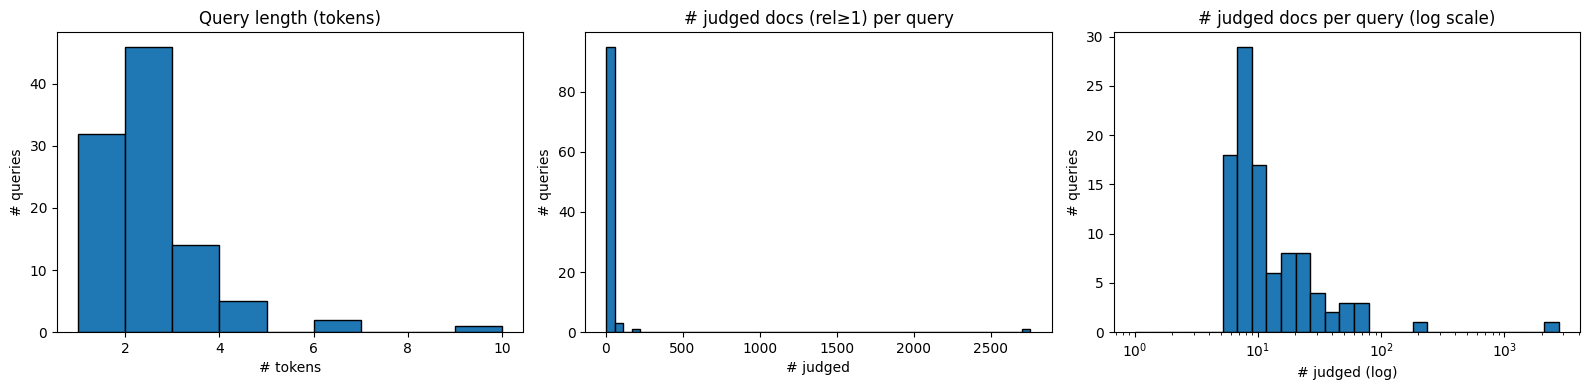

Quantiles of # judged docs (rel>=1) per query:
count     100.0
mean       44.4
std       275.1
min         6.0
10%         6.0
25%         7.0
50%         9.0
75%        19.2
90%        33.8
95%        59.5
max      2759.0
dtype: float64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(test_q_lens, bins=range(1, test_q_lens.max()+2), edgecolor='black')
axes[0].set_title('Query length (tokens)')
axes[0].set_xlabel('# tokens'); axes[0].set_ylabel('# queries')

axes[1].hist(rel_per_q, bins=50, edgecolor='black')
axes[1].set_title('# judged docs (rel≥1) per query')
axes[1].set_xlabel('# judged'); axes[1].set_ylabel('# queries')

axes[2].hist(rel_per_q, bins=np.logspace(0, np.log10(rel_per_q.max()+1), 30), edgecolor='black')
axes[2].set_xscale('log')
axes[2].set_title('# judged docs per query (log scale)')
axes[2].set_xlabel('# judged (log)'); axes[2].set_ylabel('# queries')

plt.tight_layout(); plt.show()

print('Quantiles of # judged docs (rel>=1) per query:')
print(rel_per_q.describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(1))

## 2. Прогон tf-idf и BM25 на трёх вариантах коллекции

In [7]:
! mkdir /kaggle/working/cache
! mkdir /kaggle/working/runs

In [8]:
TOP_K = 1000
cache_path = '/kaggle/working/cache'
runs_dir = '/kaggle/working/runs'

def cached(name, fn):
    p = f'{cache_path}/{name}.pkl.gz'
    if p in os.listdir(cache_path):
        with gzip.open(p, 'rb') as f:
            return pickle.load(f)
    obj = fn()
    with gzip.open(p, 'wb') as f:
        pickle.dump(obj, f, protocol=4)
    return obj

### 2.1. Стэмминг и лемматизация 

In [12]:
stemmer = PorterStemmer()
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
_stem_cache = {}

def tok(s):
    return [t.lower() for t in s.split() if any(c.isalnum() for c in t)]

def stem_tokens(toks):
    out = []
    for t in toks:
        s = _stem_cache.get(t)
        if s is None:
            s = stemmer.stem(t); _stem_cache[t] = s
        out.append(s)
    return out

def lemma_pipe(texts, batch=512, n_process=1):
    for doc in nlp.pipe(texts, batch_size=batch, n_process=n_process):
        yield [t.lemma_.lower() for t in doc if any(c.isalnum() for c in t.text)]

In [10]:
doc_ids = docs_df['doc_id'].astype(str).tolist()
doc_texts = docs_df['text'].astype(str).tolist()

print('Tokenize raw...')
docs_raw = cached('docs_raw', lambda: [tok(t) for t in tqdm(doc_texts)])

print('Stem...')
docs_stem = cached('docs_stem', lambda: [stem_tokens(d) for d in tqdm(docs_raw)])

print('Lemmatize (spaCy)...')
docs_lemma = cached('docs_lemma', lambda: list(tqdm(lemma_pipe(doc_texts), 
                                                    total=len(doc_texts))))

print(f'raw={len(docs_raw)}, stem={len(docs_stem)}, lemma={len(docs_lemma)}')

Tokenize raw...


  0%|          | 0/369721 [00:00<?, ?it/s]

Stem...


  0%|          | 0/369721 [00:00<?, ?it/s]

Lemmatize (spaCy)...


  0%|          | 0/369721 [00:00<?, ?it/s]

raw=369721, stem=369721, lemma=369721


In [ ]:
def prepare_queries(q_df, name_prefix):
    qids = q_df['doc_id'].astype(str).tolist()
    texts = q_df['text'].astype(str).tolist()
    raw = [tok(t) for t in texts]
    stm = [stem_tokens(q) for q in raw]
    lem = list(lemma_pipe(texts))
    for var_name, qs in [('raw', raw), ('stem', stm), ('lemma', lem)]:
        empty = [qid for qid, q in zip(qids, qs) if not q]
        if empty:
            print(f'[{name_prefix}/{var_name}] empty queries: {empty}')
    return qids, {'raw': raw, 'stem': stm, 'lemma': lem}

test_qids, test_q_variants = prepare_queries(test_q_df, 'test')
val_qids,  val_q_variants  = prepare_queries(val_q_df,  'val')

print('Пример test query (raw):',   ' '.join(test_q_variants['raw'][0]))
print('  stem:',  ' '.join(test_q_variants['stem'][0]))
print('  lemma:', ' '.join(test_q_variants['lemma'][0]))

### 2.2. tf-idf поиск

In [20]:
def build_tfidf(docs_tokens):
    vec = TfidfVectorizer(
        analyzer=lambda x: x,
        preprocessor=lambda x: x,
        lowercase=False,
        token_pattern=None,
    )
    X = vec.fit_transform(docs_tokens)
    X = normalize(X, norm='l2', axis=1)
    return vec, X

def tfidf_search(vec, X_norm, q_tokens_list, qids, doc_ids, top_k=TOP_K):
    Q = vec.transform(q_tokens_list)
    Q = normalize(Q, norm='l2', axis=1)
    run = {}
    for j, qid in enumerate(qids):
        s = (X_norm @ Q[j].T).toarray().ravel()
        if top_k < len(s):
            idx = np.argpartition(-s, top_k)[:top_k]
            idx = idx[np.argsort(-s[idx])]
        else:
            idx = np.argsort(-s)
        run[qid] = [(doc_ids[i], float(s[i])) for i in idx if s[i] > 0]
    return run

### 2.3. BM25 поиск

In [22]:
def build_bm25(docs_tokens, k1=1.5, b=0.75):
    return BM25Okapi(docs_tokens, k1=k1, b=b)

def bm25_search(bm25, q_tokens_list, qids, doc_ids, top_k=TOP_K):
    run = {}
    for qid, q in zip(qids, q_tokens_list):
        if not q:
            run[qid] = []
            continue
        scores = bm25.get_scores(q)
        if top_k < len(scores):
            idx = np.argpartition(-scores, top_k)[:top_k]
            idx = idx[np.argsort(-scores[idx])]
        else:
            idx = np.argsort(-scores)
        run[qid] = [(doc_ids[i], float(scores[i])) for i in idx if scores[i] > 0]
    return run

In [16]:
# построение индексов
VARIANTS = {'raw': docs_raw, 'stem': docs_stem, 'lemma': docs_lemma}
tfidf_index = {}
bm25_index  = {}
build_times = {}

for name, docs in VARIANTS.items():
    t0 = time.time()
    tfidf_index[name] = build_tfidf(docs)
    t1 = time.time()
    bm25_index[name]  = build_bm25(docs)
    t2 = time.time()
    build_times[name] = {
        'tfidf_build_s': round(t1 - t0, 2),
        'bm25_build_s':  round(t2 - t1, 2),
    }
    print(name, build_times[name])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:523: UserWarning: The parameter 'preprocessor' will not be used since 'analyzer' is callable'
  warnings.warn(


raw {'tfidf_build_s': 28.53, 'bm25_build_s': 20.09}
stem {'tfidf_build_s': 25.79, 'bm25_build_s': 16.84}
lemma {'tfidf_build_s': 29.68, 'bm25_build_s': 21.07}


In [17]:
pd.DataFrame(build_times).T

,tfidf_build_s,bm25_build_s
raw,28.53,20.09
stem,25.79,16.84
lemma,29.68,21.07


In [18]:
# прогон запросов
runs = {}
search_times = {}

for name in VARIANTS:
    vec, X = tfidf_index[name]
    bm25 = bm25_index[name]
    q = test_q_variants[name]

    t0 = time.time()
    runs[f'tfidf_{name}'] = tfidf_search(vec, X, q, test_qids, doc_ids)
    t1 = time.time()
    runs[f'bm25_{name}'] = bm25_search(bm25, q, test_qids, doc_ids)
    t2 = time.time()

    search_times[f'tfidf_{name}'] = round(t1 - t0, 2)
    search_times[f'bm25_{name}']  = round(t2 - t1, 2)
    print(f'{name}: tfidf={t1-t0:.1f}s, bm25={t2-t1:.1f}s')

raw: tfidf=23.4s, bm25=39.3s
stem: tfidf=21.3s, bm25=32.9s
lemma: tfidf=21.3s, bm25=38.9s


In [21]:
# запись в trec
def write_run(run, path, tag='run'):
    with open(path, 'w') as f:
        for qid, results in run.items():
            for rank, (docid, score) in enumerate(results, 1):
                f.write(f'{qid} Q0 {docid} {rank} {score:.6f} {tag}\n')

for tag, run in runs.items():
    write_run(run, f'{runs_dir}/{tag}.txt', tag=tag)

In [22]:
rows = []
for tag, t_search in search_times.items():
    model, variant = tag.split('_', 1)
    rows.append({
        'model':   model,
        'variant': variant,
        'build_s':         build_times[variant][f'{model}_build_s'],
        'search_total_s':  t_search,
        'per_query_ms':    round(t_search * 1000 / len(test_qids), 1),
    })
times_df = pd.DataFrame(rows).set_index(['model','variant']).sort_index()
times_df

build_s  search_total_s  per_query_ms
model variant                                       
bm25  lemma      21.07           38.92         389.2
      raw        20.09           39.26         392.6
      stem       16.84           32.87         328.7
tfidf lemma      29.68           21.26         212.6
      raw        28.53           23.40         234.0
      stem       25.79           21.30         213.0

---
## 3. Оценка ранов через `ir-measures`

Параметры метрик:
- P(cutoff=k, rel=1):
    - cutoff: на какой позиции отсекаем (top-k)
    - rel=1: порог бинаризации; документ считается релевантным, если qrel >= rel.
- AP(rel=1):
    - rel=1: порог бинаризации, аналогично P.
    - Без cutoff: AP усредняет precision на позициях всех релевантных в run.
- MAP = mean(AP) по запросам
- nDCG(cutoff=20, dcg='log2'):
    - cutoff=20: ранжирование оценивается до позиции 20.
    - dcg='log2' (default): linear gain, gain_i = rel_i / log2(i+1).

In [ ]:
import ir_measures
from ir_measures import P, MAP, nDCG, read_trec_run

MEASURES = [
    P(rel=1) @ 1,
    P(rel=1) @ 10,
    P(rel=1) @ 20,
    MAP(rel=1),
    nDCG(dcg='log2') @ 20,
]

rows = []
for tag in runs.keys():
    run_path = f'{runs_dir}/{tag}.txt'
    res = ir_measures.calc_aggregate(MEASURES, test_qrels, read_trec_run(str(run_path)))
    rows.append({'run': tag, **{str(m): res[m] for m in MEASURES}})

results_df = pd.DataFrame(rows).set_index('run')
display(results_df.round(4))
results_df.round(4).to_csv('/kaggle/working/results_test.csv')

,P@1,P@10,P@20,AP,nDCG@20
run,,,,,
tfidf_raw,0.51,0.203,0.1350,0.1655,0.3499
bm25_raw,0.49,0.212,0.1500,0.1752,0.3570
tfidf_stem,0.50,0.194,0.1285,0.1595,0.3354
bm25_stem,0.49,0.209,0.1455,0.1742,0.3540
tfidf_lemma,0.48,0.200,0.1300,0.1614,0.3391
bm25_lemma,0.48,0.210,0.1480,0.1754,0.3561


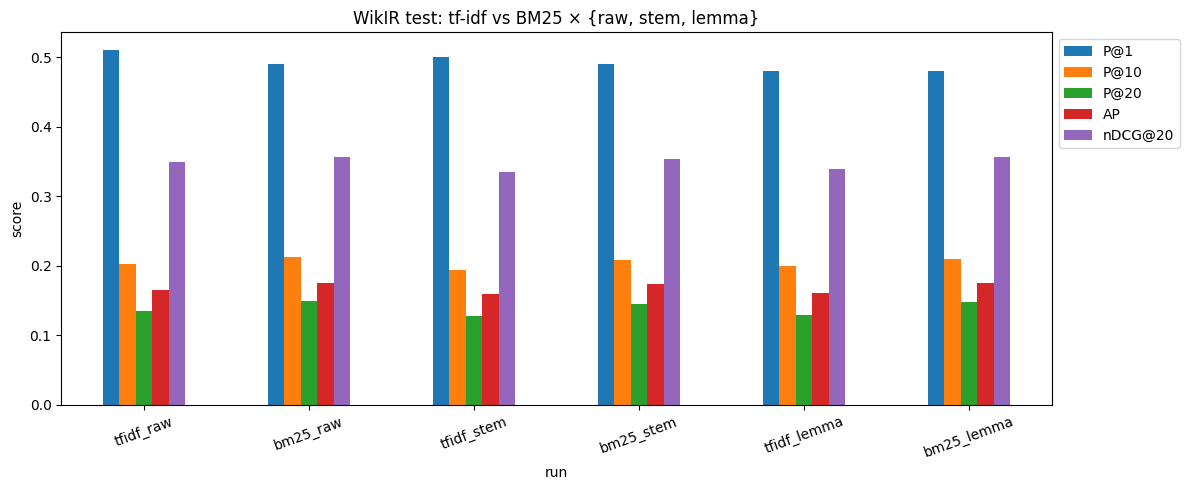

In [ ]:
ax = results_df.plot(kind='bar', figsize=(12, 5), rot=20)
ax.set_ylabel('score'); ax.set_title('WikIR test: tf-idf vs BM25 × {raw, stem, lemma}')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()

**bm25_raw — лучший по абсолютному значению nDCG@20**, но различие с bm25_lemma (0.3570 vs 0.3561) находится в пределах шума. Можно сделать из этого выводы: 
- морфология вредит, особенно stemming
- BM25 чуть предпочтительнее чем tf-idf, но различие не значительно.

## 4. Анализ

### 4.1. Подготовка: per-query метрики

Для последующего анализа считаем посчитаем per-query метрики nDCG@20 для каждого из 100 тестовых запросов в каждом из 6 ранов. Результат - таблица `big_perq`, которая будет источником данных для всех дальнейших вопросов

In [56]:
MEASURES = [
    P(rel=1) @ 1,
    P(rel=1) @ 10,
    P(rel=1) @ 20,
    MAP(rel=1),
    nDCG(dcg='log2') @ 20,
]
MEASURE_NAMES = ['P@1', 'P@10', 'P@20', 'MAP', 'nDCG@20']
RUN_TAGS = list(runs.keys())

rows = []
for tag in RUN_TAGS:
    run_path = f'{runs_dir}/{tag}.txt'
    for r in iter_calc(MEASURES, test_qrels, read_trec_run(str(run_path))):
        rows.append({'qid': r.query_id, 'run': tag,
                     'measure': str(r.measure), 'value': r.value})
big_perq = pd.DataFrame(rows)

perq_wide = big_perq.pivot_table(index='qid', columns=['run', 'measure'], values='value')
print('big_perq:', big_perq.shape, '   perq_wide:', perq_wide.shape)
perq_wide.head(3)

big_perq: (3000, 4)    perq_wide: (100, 30)


run     bm25_lemma                           bm25_raw                  \
measure         AP  P@1 P@10 P@20   nDCG@20        AP  P@1 P@10  P@20   
qid                                                                     
101626    0.180299  1.0  0.3  0.2  0.433706  0.182596  1.0  0.4  0.25   
10166     0.167894  0.0  0.2  0.3  0.289004  0.179776  0.0  0.2  0.35   
104086    0.445832  1.0  0.4  0.3  0.716428  0.445832  1.0  0.4  0.30   

run                ... tfidf_raw                           tfidf_stem       \
measure   nDCG@20  ...        AP  P@1 P@10  P@20   nDCG@20         AP  P@1   
qid                ...                                                       
101626   0.448147  ...  0.115890  1.0  0.3  0.15  0.352967   0.097721  1.0   
10166    0.324204  ...  0.143114  0.0  0.2  0.15  0.247398   0.129725  0.0   
104086   0.716428  ...  0.471560  1.0  0.4  0.30  0.725170   0.491987  1.0   

run                           
measure P@10  P@20   nDCG@20  
qid                           
101626   0.2  0.15  0.339183  
10166    0.2  0.20  0.229129  
104086   0.5  0.30  0.733329  

[3 rows x 30 columns]

### 4. 1. Легкие vs сложные запросы

Идея: запрос "сложный", если он получает низкие метрики во многих ранах.  Чтобы определить "сложные" и "лёгкие" запросы устойчиво, для каждой пары (run, measure) выполняется z-score-нормализация per-query значений, затем усреднение по 30 комбинациям. Это показывает, то насколько запрос систематически сложен/лёгок по разным метрикам и моделям. Параллельно считается `frac_hard` / `frac_easy` — доля комбинаций (из 30), где запрос попал в нижний/верхний дециль.

In [ ]:
from scipy.stats import zscore

z = perq_wide.apply(zscore, nan_policy='omit')   # z-score по столбцам
difficulty = z.mean(axis=1).sort_values()        # low = hard, high = easy

def pct_in_bucket(series, lower=True):
    cutoff = series.quantile(0.1 if lower else 0.9)
    return (series <= cutoff).mean() if lower else (series >= cutoff).mean()

frac_hard = perq_wide.apply(lambda col: col <= col.quantile(0.1)).mean(axis=1)
frac_easy = perq_wide.apply(lambda col: col >= col.quantile(0.9)).mean(axis=1)

q_text_map = dict(zip(test_q_df['doc_id'].astype(str), test_q_df['text'].astype(str)))
q_len_map  = dict(zip(test_q_df['doc_id'].astype(str), test_q_lens.values))

print('=== Hard queries ===')
print(f'{"qid":>8}  {"diff_z":>6}  {"frac_hard":>9}  {"qlen":>4}  query')
for qid in difficulty.head(10).index:
    print(f'{qid:>8}  {difficulty[qid]:+.2f}    {frac_hard[qid]:>5.2f}      '
          f'{q_len_map.get(qid, "?"):>4}  {q_text_map.get(qid, "")[:60]}')

print('\n=== Easy queries ===')
print(f'{"qid":>8}  {"diff_z":>6}  {"frac_easy":>9}  {"qlen":>4}  query')
for qid in difficulty.tail(10).index:
    print(f'{qid:>8}  {difficulty[qid]:+.2f}    {frac_easy[qid]:>5.2f}      '
          f'{q_len_map.get(qid, "?"):>4}  {q_text_map.get(qid, "")[:60]}')

=== Hard queries ===
     qid  diff_z  frac_hard  qlen  query
 1897191  -1.32     1.00         1  centrism
   83078  -1.32     1.00         1  pomacentridae
   79032  -1.31     1.00         2  elijah wood
  738573  -1.27     1.00         2  television presenter
  641464  -1.13     1.00         4  brisbane central business district
    5622  -1.08     0.73         1  homer
 1280405  -1.08     0.77         2  japanese americans
  206019  -1.06     0.73         2  billboard 200
  158491  -1.02     0.73         3  southern methodist university
    7911  -1.01     0.67         1  medicine

=== Easy queries ===
     qid  diff_z  frac_easy  qlen  query
  265104  +0.97     0.40         1  allsvenskan
    8140  +1.24     0.80         2  michael moorcock
   87686  +1.43     0.80         1  evesham
  113000  +1.47     0.80         1  sulfide
   75295  +1.52     0.63         3  dave matthews band
  104086  +1.58     1.00         1  bulacan
  267973  +1.64     0.90         2  gambela region
  12138

Из десяти "сложных" запросов пять имеют frac_hard = 1.00, то есть они стабильно сложны во всех 30 (run, measure)-комбинациях. Это не артефакт выбора метрики или модели. Остальные пять имеют frac_hard 0.67–0.77 — сложны "в большинстве случаев", что тоже устойчиво.

Hard-запросы можно поделить на две группы:
- семантически неоднозначные общие термины (`homer` (симпсон или автор Иллиады?), `medicine` (таблетки или медицина?), `television presenter` (какой из?)): слова с большой частотой в коллекции, BM25/tf-idf не могут различить "правильные" документы (те, которые в разметке помечены как релевантные) от десятков других, упоминающих этот термин.
- более специфичные и редкие термины (`pomacentridae`, `elijah wood`, `brisbane central business district`, `southern methodist university`)

Easy-запросы все одного типа: редкие специфичные термины (топонимы, названия групп, технические термины), для которых просто найти правильный релевантный документ

### 4.2. Влияние характеристик запросов
Посмотрим на влияние:
- длины запроса в токенах
- avg/max/min idf по терминам запроса
- есть ли в запросе хотя бы один редкий термин (max_idf > median)?

Для этого считаем корреляцию свойств запроса с каждой из 5 метрик, усреднённых по всем 6 ранам

In [65]:
MEASURE_NAMES = ['P@1', 'P@10', 'P@20', 'AP', 'nDCG@20']
N = len(docs_raw)
df_counter = Counter()
for d in docs_raw:
    for t in set(d):
        df_counter[t] += 1
def term_idf(t):
    return log(N / (1 + df_counter.get(t, 0)))

q_tokens_raw = test_q_variants['raw']
q_props = pd.DataFrame({
    'qid':     test_qids,
    'length':  [len(q) for q in q_tokens_raw],
    'avg_idf': [np.mean([term_idf(t) for t in q]) if q else 0 for q in q_tokens_raw],
    'max_idf': [max([term_idf(t) for t in q]) if q else 0 for q in q_tokens_raw],
    'min_idf': [min([term_idf(t) for t in q]) if q else 0 for q in q_tokens_raw],
}).set_index('qid')

# корреляция каждого свойства с каждой метрикой, усредненной по всем ранам
mean_by_measure = big_perq.groupby(['qid', 'measure'])['value'].mean().unstack()  # qid × measure
mean_by_measure = mean_by_measure[MEASURE_NAMES]  # порядок столбцов

corr_rows = []
for prop in ['length', 'avg_idf', 'max_idf', 'min_idf']:
    row = {'property': prop}
    for m in MEASURE_NAMES:
        common = q_props.index.intersection(mean_by_measure.index)
        rho, p = spearmanr(q_props.loc[common, prop], mean_by_measure.loc[common, m])
        row[m] = f'{rho:+.2f}{"*" if p<0.05 else ""}{"*" if p<0.01 else ""}'
    corr_rows.append(row)
corr_df = pd.DataFrame(corr_rows).set_index('property')
print('Spearman ρ (query property × metric, mean across 6 runs)')
print('* = p<0.05, ** = p<0.01')
display(corr_df)

Spearman ρ (query property × metric, mean across 6 runs)
* = p<0.05, ** = p<0.01


,P@1,P@10,P@20,AP,nDCG@20
property,,,,,
length,-0.01,-0.18,-0.24*,+0.01,-0.05
avg_idf,+0.11,+0.22*,+0.23*,+0.24*,+0.23*
max_idf,+0.13,+0.16,+0.10,+0.30**,+0.29**
min_idf,+0.02,+0.13,+0.17,+0.09,+0.09


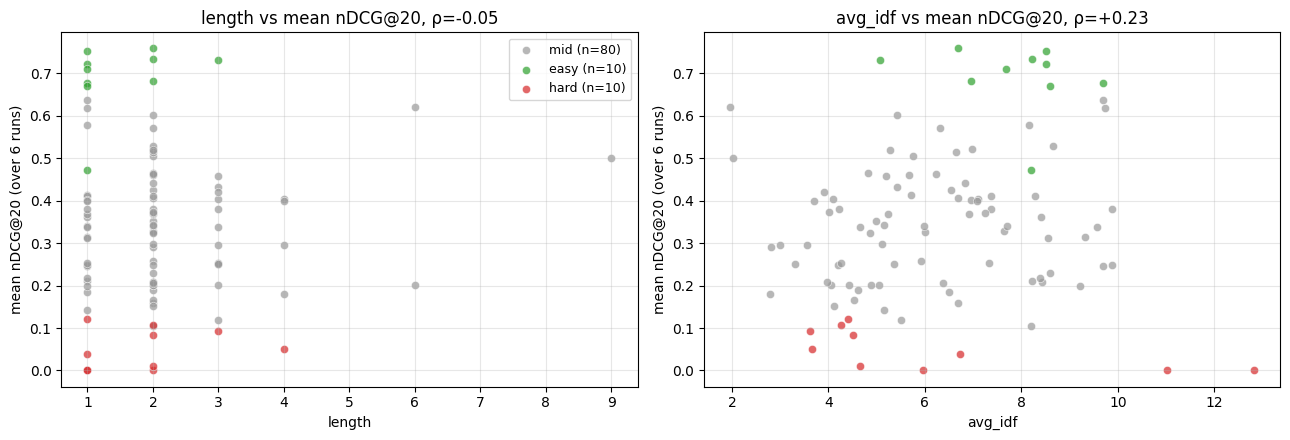

In [ ]:
# Визуализация для основных свойств: длина и avg_idf vs nDCG@20
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ndcg_mean = mean_by_measure['nDCG@20']

# Категории по сложности из 4.1
diff_cat = pd.cut(difficulty, bins=[-np.inf, difficulty.quantile(0.1),
                                     difficulty.quantile(0.9), np.inf],
                  labels=['hard', 'mid', 'easy'])
colors_map = {'hard': '#d62728', 'mid': '#999999', 'easy': '#2ca02c'}
common = q_props.index.intersection(ndcg_mean.index).intersection(diff_cat.index)

for ax, prop in zip(axes, ['length', 'avg_idf']):
    for c in ['mid', 'easy', 'hard']:
        mask_idx = [i for i in common if diff_cat.loc[i] == c]
        ax.scatter(q_props.loc[mask_idx, prop], ndcg_mean.loc[mask_idx],
                   c=colors_map[c], alpha=0.7, s=35,
                   edgecolors='white', linewidths=0.5,
                   label=f'{c} (n={len(mask_idx)})')
    rho, p = spearmanr(q_props.loc[common, prop], ndcg_mean.loc[common])
    ax.set_xlabel(prop); ax.set_ylabel('mean nDCG@20 (over 6 runs)')
    ax.set_title(f'{prop} vs mean nDCG@20, ρ={rho:+.2f}')
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

Длина запроса:
- Для P@1, AP, nDCG@20 — корреляция близка к нулю (|ρ| ≤ 0.05, не значимо). Длина в среднем не предсказывает качество.
- Для P@20 ρ = −0.24 (значимо). Длинные запросы дают чуть худшее P@20 — это можно объяснить тем, что длинные запросы часто содержат конкретные именованные сущности типа "brisbane central business district", где система покрывает узкую тематику и не набирает 20 релевантных в топе.

На scatter-плоте видно, что запросы разной длины имеют идентичный разброс nDCG от 0 до 0.85. Слабая отрицательная корреляция в P@20 - это эффект небольшого числа длинных запросов, а не систематической связи.

Avg idf (средняя информативность терминов запроса):
- Значимая положительная корреляция со всеми метриками, кроме P@1.
- Чем "редче" термины запроса в среднем — тем выше качество поиска.
- Это согласуется с разделением hard/easy в 4.1

Max idf (самый редкий термин в запросе):
- Самая сильная корреляция: ρ = +0.30 для AP, +0.29 для nDCG@20 (p < 0.01).
- Это семантически осмысленно: BM25 score доминируется самым редким термом запроса, потому что у него максимальный idf-вес. Поэтому "качество" наиболее редкого термина решает успех всего запроса.
- В длинных запросах (`brisbane central business district`) max_idf высок (есть редкий "brisbane"), но avg_idf тянут вниз общие слова ("central", "business", "district"). Это объясняет, почему max_idf предсказывает сильнее avg_idf.

Min idf (самый общий термин):
- Близка к нулю — наличие в запросе общего термина не вредит. BM25 такие термины почти игнорирует через низкий idf-вес.

---
На визуализации (length и avg_idf vs mean nDCG@20):
- В левой части по длине красные (hard) и зелёные (easy) точки распределены по всем значениям 1–4 — нет систематической связи.
- В правой части по avg_idf зелёные (easy) кучкуются справа сверху (avg_idf > 7), красные (hard) — слева (avg_idf < 5) и в правом нижнем углу, что может подветрждать 4.1 и предположение о влиянии idf запроса на метрики
  
---
Длина запроса не предсказывает качество в среднем, зато информативность терминов (idf, особенно max_idf) влияет.

### 4.3. Влияние морфологической обработки

In [67]:
def paired_wilcoxon(a_tag, b_tag, measure):
    a = perq_wide[(a_tag, measure)].dropna()
    b = perq_wide[(b_tag, measure)].dropna()
    common = a.index.intersection(b.index)
    x, y = a.loc[common].values, b.loc[common].values
    if np.allclose(x, y):
        return 0.0, 1.0
    _, p = wilcoxon(x, y, zero_method='zsplit')
    return float(np.mean(y - x)), float(p)

comparisons = [
    ('BM25 stem - raw',    'bm25_raw',  'bm25_stem'),
    ('BM25 lemma - raw',   'bm25_raw',  'bm25_lemma'),
    ('BM25 stem - lemma',  'bm25_lemma','bm25_stem'),
    ('tf-idf stem - raw',  'tfidf_raw', 'tfidf_stem'),
    ('tf-idf lemma - raw', 'tfidf_raw', 'tfidf_lemma'),
    ('BM25 - tf-idf (raw)','tfidf_raw', 'bm25_raw'),
    ('BM25 - tf-idf (stem)','tfidf_stem','bm25_stem'),
]

morph_rows = []
for name, a, b in comparisons:
    row = {'comparison': name}
    for m in MEASURE_NAMES:
        diff, p = paired_wilcoxon(a, b, m)
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        row[m] = f'{diff:+.4f}{sig}'
    morph_rows.append(row)
morph_df = pd.DataFrame(morph_rows).set_index('comparison')
print('Pairwise differences (Wilcoxon) — diff = b - a, * = p<0.05, ** = p<0.01')
display(morph_df)

Pairwise differences (Wilcoxon) — diff = b - a, * = p<0.05, ** = p<0.01


,P@1,P@10,P@20,AP,nDCG@20
comparison,,,,,
BM25 stem - raw,+0.0000,-0.0030,-0.0045,-0.0010*,-0.0029*
BM25 lemma - raw,-0.0100,-0.0020,-0.0020,+0.0002,-0.0008
BM25 stem - lemma,+0.0100,-0.0010,-0.0025,-0.0012**,-0.0021
tf-idf stem - raw,-0.0100,-0.0090,-0.0065,-0.0060*,-0.0145*
tf-idf lemma - raw,-0.0300,-0.0030,-0.0050,-0.0040,-0.0107
BM25 - tf-idf (raw),-0.0200,+0.0090,+0.0150**,+0.0097*,+0.0071
BM25 - tf-idf (stem),-0.0100,+0.0150,+0.0170**,+0.0147**,+0.0186


Морфология систематически вредит.На всех 5 метриках разница `stem − raw` и `lemma − raw` отрицательна (stem чуть хуже raw, lemma чуть хуже raw). Значимость:

- Stem значимо хуже raw для AP и nDCG@20 в BM25 (p < 0.05).
- Stem значимо хуже raw для AP и nDCG@20 в tf-idf, причём эффект больше (−0.015 для nDCG@20 vs −0.003 в BM25).
- Lemma — менее агрессивная, и её эффект статистически не значим ни в одном случае.
- На P@1 и P@10 эффект морфологии не значим — это согласуется с 4.2, где P@1 был мало чувствителен к свойствам запроса.

tf-idf страдает от стемминга сильнее BM25 (−0.015 vs −0.003 на nDCG@20). Это потому что в BM25 есть насыщение tf и нормализация по длине документа — они сглаживают шум от ложных совпадений, которые создаёт стемминг (`Wales → wale`). Tf-idf без таких механизмов больше подвержен влиянию артефактов.

BM25 vs tf-idf: BM25 значимо лучше на P@20 и AP для raw и stem (p < 0.01). Для nDCG@20 разница не достигает значимости (+0.007 для raw, p > 0.05; +0.019 для stem, p > 0.05). На P@1 tf-idf даже немного впереди (на грани шума: разница −0.02, не значимо).

Запросы в WikIR — это в основном имена собственные (топонимы `volos`, `bulacan`; имена `elijah wood`, `dierks bentley`; термины `xml`, `pomacentridae`). Porter stemmer обрабатывает их по правилам и не различает обычное слово от имени собственного. Это разрушает редкие термины с высоким idf и создаёт ложные совпадения. Лемматизация обычно мягче и оставляет имена собственные в покое.

### 4.4. Корреляция метрик между собой: нужна ли одна метрика?

Для каждого рана: корреляционная матрица 5×5 между метриками. Потом усредняем.

Mean Spearman correlation between measures (averaged over 6 runs):


measure,P@1,P@10,P@20,AP,nDCG@20
measure,,,,,
P@1,1.000,0.299,0.196,0.549,0.723
P@10,0.299,1.000,0.867,0.744,0.670
P@20,0.196,0.867,1.000,0.643,0.553
AP,0.549,0.744,0.643,1.000,0.904
nDCG@20,0.723,0.670,0.553,0.904,1.000



Std of correlations across runs (low = stable across runs):


measure,P@1,P@10,P@20,AP,nDCG@20
measure,,,,,
AP,0.013,0.021,0.032,0.000,0.016
P@1,0.000,0.047,0.061,0.013,0.034
P@10,0.047,0.000,0.053,0.021,0.066
P@20,0.061,0.053,0.000,0.032,0.075
nDCG@20,0.034,0.066,0.075,0.016,0.000


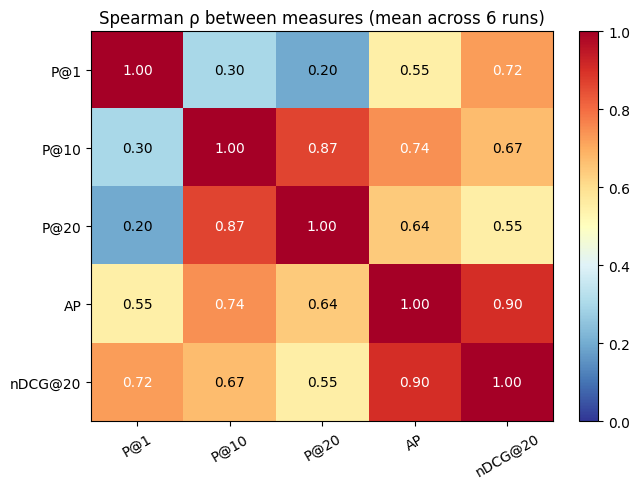

In [68]:
corr_per_run = {}
for tag in RUN_TAGS:
    sub = perq_wide[tag][MEASURE_NAMES]
    corr_per_run[tag] = sub.corr(method='spearman')

# Усреднённая матрица
corr_mean = sum(corr_per_run.values()) / len(corr_per_run)
# Стандартное отклонение — для оценки устойчивости
corr_std = pd.concat(corr_per_run).groupby(level=1).std()

print('Mean Spearman correlation between measures (averaged over 6 runs):')
display(corr_mean.round(3))
print('\nStd of correlations across runs (low = stable across runs):')
display(corr_std.round(3))

# Heatmap
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr_mean.values, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(MEASURE_NAMES))); ax.set_xticklabels(MEASURE_NAMES, rotation=30)
ax.set_yticks(range(len(MEASURE_NAMES))); ax.set_yticklabels(MEASURE_NAMES)
for i in range(len(MEASURE_NAMES)):
    for j in range(len(MEASURE_NAMES)):
        ax.text(j, i, f'{corr_mean.values[i,j]:.2f}',
                ha='center', va='center', fontsize=10,
                color='white' if corr_mean.values[i,j] > 0.7 else 'black')
ax.set_title('Spearman ρ between measures (mean across 6 runs)')
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

Std корреляций по ранам ≤ 0.08 для всех пар — выводы устойчивы и не артефакт конкретного рана.

Группы метрик:

1. AP и nDCG@20 — почти один сигнал (ρ = 0.90). Они содержат практически одинаковую информацию о качестве ранжирования по запросу. Для практической оценки достаточно одной из этих метрик.

2. P@10 и P@20 — сильно скоррелированы (ρ = 0.87), но не идентичны. Оба измеряют precision в "первой странице" с разным cutoff.

3. P@1 — отдельный сигнал. Корреляции P@1 с P@10/P@20 — только 0.20–0.30. С AP — 0.55. Только с nDCG@20 — 0.72 

4. P@20 и nDCG@20 коррелируют умеренно (ρ = 0.55). Это интересно: обе метрики используют один cutoff (20), но nDCG учитывает позиции и градации релевантности (rel=2 vs rel=1), а P@20 — только наличие в топе.

Вывод: одной метрики точно не достаточно.Минимальный осмысленный набор для WikIR — это P@1 + AP/nDCG@20:

- Только P@1: упускаем качество ранжирования (может повезти на первом месте).
- Только AP или nDCG@20: упускаем стабильность (модель может уверенно ранжировать топ-5, но никогда не находить самые релевантные документы

### 4.5. Разбор top-1 нерелевантных

In [71]:
# Для каждого рана: сколько запросов имеют top-1 вне qrels?
top1_stats = []
for tag in RUN_TAGS:
    run = runs[tag]
    n_outside = 0
    examples_collected = []
    for qid, results in run.items():
        if not results: continue
        top_doc, top_score = results[0]
        if top_doc not in test_qrels.get(qid, {}):
            n_outside += 1
            if len(examples_collected) < 3:
                examples_collected.append((qid, top_doc, top_score))
    top1_stats.append({
        'run': tag,
        'top1 outside qrels': n_outside,
        'pct': f'{n_outside}%',
    })
top1_df = pd.DataFrame(top1_stats).set_index('run')
display(top1_df)

# Детальный разбор для одного рана — берём тот, где больше всего нерелевантных top-1
# (логично разбирать самый проблемный)
worst_tag = top1_df['top1 outside qrels'].idxmax()
print(f'\Детальный вывод для запуска {worst_tag} (больше всего нерелевантных top-1):')
doc_text_map = dict(zip(docs_df['doc_id'].astype(str), docs_df['text'].astype(str)))
best_run = runs[worst_tag]
examples = []
for qid, results in best_run.items():
    if not results: continue
    top_doc, top_score = results[0]
    if top_doc not in test_qrels.get(qid, {}):
        examples.append((qid, top_doc, top_score))

print(f'Всего нерелевантных top-1: {len(examples)} / {len(best_run)}\n')
for qid, did, sc in examples[:5]:
    print('-' * 80)
    print(f'qid={qid}  query: {q_text_map.get(qid, "")[:120]}')
    print(f'top-1 doc={did}  score={sc:.2f}')
    print(f'doc text: {doc_text_map.get(did, "")[:250]}')

# Пересекаются ли top-1 вне qrels запросы между ранами?
top1_outside_by_run = {}
for tag in RUN_TAGS:
    s = set()
    for qid, results in runs[tag].items():
        if results and results[0][0] not in test_qrels.get(qid, {}):
            s.add(qid)
    top1_outside_by_run[tag] = s

intersection = set.intersection(*top1_outside_by_run.values())
union = set.union(*top1_outside_by_run.values())
print(f'\Запросы с top-1 вне qrels во ВСЕХ 6 случаях: {len(intersection)}')
print(f'Запросы с top-1 вне qrels МИНИМУМ в одном случае: {len(union)}')

,top1 outside qrels,pct
run,,
tfidf_raw,48,48%
bm25_raw,49,49%
tfidf_stem,49,49%
bm25_stem,49,49%
tfidf_lemma,51,51%
bm25_lemma,50,50%


\Детальный вывод для запуска tfidf_lemma (больше всего нерелевантных top-1):
Всего нерелевантных top-1: 51 / 100

--------------------------------------------------------------------------------
qid=158491  query: southern methodist university
top-1 doc=526708  score=0.53
doc text: based in nashville tn cokesbury serves as an agency of the united methodist church but serves also as an ecumenical resource provider to other denominations the history of the united methodist publishing house dates back officially to 1789 as its col
--------------------------------------------------------------------------------
qid=406391  query: dierks bentley
top-1 doc=40342  score=0.51
doc text: the population was 1 133 at the 2010 census down from 1 230 in 2000 dierks was formerly known as hardscrabble it was then changed to dierks after hans dierks the oldest of four brothers who owned the dierks lumber and coal company in 2007 dierks cele
--------------------------------------------------------------

49–51% запросов имеют нерелевантные top-1 во всех 6 ранах, то есть это не последствия одной модели/обработки данных

Пересечения между ранами:
- В всех 6 ранах top-1 вне qrels — 38 запросов (38%). Это запросы, где модель стабильно неправа по меркам разметки.
- В хотя бы одном ране — 60 запросов (60%). То есть для 60% запросов хотя бы одна модель находит на первом месте нерелевантный документ 

Больше всего нерелевантных top-1 в tfidf_lemma:

| qid | query | top-1 фактически |
|---|---|---|
| 158491 | southern methodist university | Cokesbury — издательство Methodist Church (тематически близко: methodist, university press) |
| 406391 | dierks bentley | город Dierks (другой смысл "dierks", но контекст связан — фамилия) |
| 5115 | goidelic languages | статья про культурные и языковые сходства британско-римского периода (тематически близко) |
| 62953 | kalmar county | город Калмар, его столица (содержательно полностью релевантно!) |
| 152444 | manawatu wanganui | житель Wanganui, профсоюзный деятель (тематически связано) |

В 4 из 5 случаев top-1 — это документ, содержательно близкий запросу, но ему не релевантный, в 1 случае (на мой взгляд) - полностью релевантный (но возможно отсутствующий в разметке). Посмотрим на то, что считается релеватным для каждого запроса в разметке

In [ ]:
QUERIES_TO_INSPECT = ['158491', '406391', '5115', '62953', '152444']

for qid in QUERIES_TO_INSPECT:
    query_text = q_text_map.get(qid, '')
    qrel = test_qrels.get(qid, {})
    
    print('=' * 100)
    print(f'qid={qid}   query: "{query_text}"')
    print(f'#judged: {len(qrel)}  (rel=2: {sum(1 for r in qrel.values() if r==2)}, '
          f'rel=1: {sum(1 for r in qrel.values() if r==1)})')
    
    # Что модель поставила в top-1
    top_doc, top_score = runs['tfidf_lemma'][qid][0]
    print(f'\nSYSTEM TOP-1:  doc={top_doc}  score={top_score:.2f}  '
          f'in_qrels={top_doc in qrel}')
    print(f'  text: {doc_text_map.get(top_doc, "")[:280]}')
    
    # Source article (rel=2)
    source_docs = [d for d, r in qrel.items() if r == 2]
    print(f'\nSOURCE ARTICLE (rel=2):')
    for d in source_docs:
        print(f'  doc={d}')
        print(f'  text: {doc_text_map.get(d, "")[:280]}')
    
    # Несколько примеров связанных документов (rel=1)
    related_docs = [d for d, r in qrel.items() if r == 1]
    print(f'\nLINKED ARTICLES (rel=1, показываем первые 3 из {len(related_docs)}):')
    for d in related_docs[:3]:
        print(f'  doc={d}')
        print(f'  text: {doc_text_map.get(d, "")[:200]}')
    print()

qid=158491   query: "southern methodist university"
#judged: 9  (rel=2: 1, rel=1: 8)

SYSTEM TOP-1:  doc=526708  score=0.53  in_qrels=False
  text: based in nashville tn cokesbury serves as an agency of the united methodist church but serves also as an ecumenical resource provider to other denominations the history of the united methodist publishing house dates back officially to 1789 as its colophon and official trademark b

SOURCE ARTICLE (rel=2):
  doc=158491
  text: smu also operates satellite campuses in plano texas and taos new mexico founded in 1911 by the methodist episcopal church south smu is owned by the south central jurisdiction of what is now the united methodist church there are more catholics enrolled than methodists and the univ

LINKED ARTICLES (rel=1, показываем первые 3 из 8):
  doc=2130828
  text: he led the smu mustangs to two southwest conference championships mcilhenny is considered to be one of the greatest option quarterbacks in ncaa division i a history as a 

Я по большей части согласна с суждениями. Из 5 проверенных примеров:
   - 1 случай (kalmar county): top-1 модели более семантически релевантен, чем связанные статьи
   - 1 случай (manawatu wanganui) — top-1 узко-релевантен через одно слово запроса
   - 3 случая (southern methodist university, dierks bentley, goidelic languages) — top-1 модели действительно либо ошибочен, либо смысловая близость минимальна.

## 5. Подбор k1 и b на валидации

Используем raw-вариант, так как показал себя лучше всех (хоть и незначительно). Оптимизируем метрику nDCG@20 (поддерживает многоуровневую шкалу ранжирования, имеет cutoff соответствующий типичной первой странице выдачи; сильно коррелирует с AP, поэтому оптимизация по nDCG@20 практически эквивалентна оптимизации по AP) 

In [74]:
TUNE_VARIANT = 'raw'
tune_docs = VARIANTS[TUNE_VARIANT]
tune_q = val_q_variants[TUNE_VARIANT]

K1_GRID = [0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4]
B_GRID = [0.0, 0.2, 0.4, 0.6, 0.75, 0.8, 1.0]
TARGET = nDCG(dcg='log2') @ 20

grid = pd.DataFrame(index=K1_GRID, columns=B_GRID, dtype=float)
for k1 in tqdm(K1_GRID, desc='k1'):
    for b in B_GRID:
        bm = BM25Okapi(tune_docs, k1=k1, b=b)
        run = bm25_search(bm, tune_q, val_qids, doc_ids, top_k=TOP_K)
        score = ir_measures.calc_aggregate([TARGET], val_qrels, format_run(run))[TARGET]
        grid.loc[k1, b] = score
grid.round(4)

k1:   0%|          | 0/7 [00:00<?, ?it/s]

,0.00,0.20,0.40,0.60,0.75,0.80,1.00
0.6,0.3211,0.3186,0.3184,0.3184,0.3183,0.3182,0.3182
0.9,0.3181,0.3156,0.3162,0.3161,0.3161,0.3161,0.3163
1.2,0.3171,0.3149,0.3148,0.3148,0.3152,0.3152,0.3155
1.5,0.3190,0.3172,0.3166,0.3168,0.3168,0.3167,0.3164
1.8,0.3186,0.3168,0.3162,0.3160,0.3157,0.3157,0.3160
2.1,0.3155,0.3142,0.3136,0.3136,0.3131,0.3131,0.3132
2.4,0.3159,0.3138,0.3136,0.3138,0.3138,0.3135,0.3134


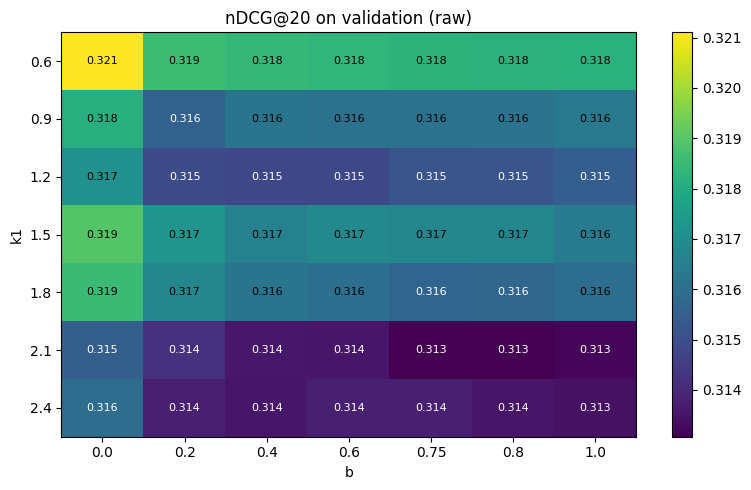

Best: k1=0.6, b=0.0, nDCG@20(val)=0.3211
Default (1.5, 0.75)   nDCG@20(val)=0.3168


In [75]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(grid.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(B_GRID))); ax.set_xticklabels(B_GRID)
ax.set_yticks(range(len(K1_GRID))); ax.set_yticklabels(K1_GRID)
ax.set_xlabel('b'); ax.set_ylabel('k1')
ax.set_title(f'nDCG@20 on validation ({TUNE_VARIANT})')
for i in range(len(K1_GRID)):
    for j in range(len(B_GRID)):
        ax.text(j, i, f'{grid.values[i, j]:.3f}', ha='center', va='center',
                color='white' if grid.values[i, j] < grid.values.mean() else 'black', fontsize=8)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

best_k1, best_b = grid.stack().idxmax()
print(f'Best: k1={best_k1}, b={best_b}, nDCG@20(val)={grid.loc[best_k1, best_b]:.4f}')
print(f'Default (1.5, 0.75)   nDCG@20(val)={grid.loc[1.5, 0.75]:.4f}')

Весь grid лежит в диапазоне [0.3131, 0.3211] — разброс 0.008 (~2.5%). Нет явно выраженного оптимума; различия между большинством соседних точек — на уровне последнего знака.

Лучшие значения — в столбце `b=0.0`. Для всех k1 наибольший результат достигается при `b=0.0` (отключённая нормализация по длине документа). Это означает: на WikIR-документах штраф за длину документа в среднем не помогает или даже вредит

Высокие k1 (≥2.1) систематически хуже (все значения ≤ 0.3159). Большое k1 увеличивает чувствительность к term frequency в отдельном документе. На коротких запросах из 2 редких терминов это контрпродуктивно — система начинает "переоценивать" документы с большим числом повторений одного из терминов, что не коррелирует с релевантностью.

Best (0.6, 0.0) — на границе сетки. Это сигнал, что мог бы быть смысл расширить сетку (влево (b < 0) технически невозможно) вниз (k1 < 0.6), но такие значения уже выходят за разумный диапазон BM25 

In [77]:
# Прогон тюненных параметров на тестовом наборе
bm25_tuned = BM25Okapi(tune_docs, k1=best_k1, b=best_b)
tuned_run = bm25_search(bm25_tuned, test_q_variants[TUNE_VARIANT], test_qids, doc_ids)
tag_tuned = f'bm25_{TUNE_VARIANT}_tuned'
write_run(tuned_run, f'{runs_dir}/{tag_tuned}.txt', tag=tag_tuned)

tuned_metrics = ir_measures.calc_aggregate(MEASURES, test_qrels, format_run(tuned_run))
tuned_row = pd.Series({name: tuned_metrics[m] for name, m in zip(MEASURE_NAMES, MEASURES)},
                       name=tag_tuned)
final_table = pd.concat([results_df, tuned_row.to_frame().T])
final_table.round(4)

,P@1,P@10,P@20,AP,nDCG@20
tfidf_raw,0.51,0.203,0.1350,0.1655,0.3499
bm25_raw,0.49,0.212,0.1500,0.1752,0.3570
tfidf_stem,0.50,0.194,0.1285,0.1595,0.3354
bm25_stem,0.49,0.209,0.1455,0.1742,0.3540
tfidf_lemma,0.48,0.200,0.1300,0.1614,0.3391
bm25_lemma,0.48,0.210,0.1480,0.1754,0.3561
bm25_raw_tuned,0.50,0.211,0.1465,0.1727,0.3522


In [78]:
default_row = results_df.loc[f'bm25_{TUNE_VARIANT}']
diff_row    = (tuned_row - default_row).rename(f'Δ vs default')
final_table = pd.concat([
    default_row.to_frame().T.rename(index={f'bm25_{TUNE_VARIANT}':
                                            f'bm25_{TUNE_VARIANT} (default)'}),
    tuned_row.to_frame().T,
    diff_row.to_frame().T,
])
print('\nFinal comparison on TEST set:')
display(final_table.round(4))


Final comparison on TEST set:


,P@1,P@10,P@20,AP,nDCG@20
bm25_raw (default),0.49,0.212,0.1500,0.1752,0.3570
bm25_raw_tuned,0.50,0.211,0.1465,0.1727,0.3522
Δ vs default,0.01,-0.001,-0.0035,-0.0025,-0.0047


На test tuned параметры дают результат хуже default по всем метрикам, кроме P@1. На primary metric (nDCG@20) разница −0.0047 — направление противоположно тому, что мы видели на validation.

### Wilcoxon paired test между tuned и default per-query nDCG@20

In [ ]:
from scipy.stats import wilcoxon
tuned_perq = {r.query_id: r.value for r in iter_calc(
    [TARGET], test_qrels, read_trec_run(f'{runs_dir}/{tag_tuned}.txt'))}
default_perq = {r.query_id: r.value for r in iter_calc(
    [TARGET], test_qrels, read_trec_run(f'{runs_dir}/bm25_{TUNE_VARIANT}.txt'))}

common = sorted(set(tuned_perq) & set(default_perq))
x = np.array([default_perq[q] for q in common])
y = np.array([tuned_perq[q]   for q in common])

if np.allclose(x, y):
    print(f'\nTuned параметры дают идентичные результаты с default.')
else:
    _, p = wilcoxon(x, y, zero_method='zsplit')
    diff = float(np.mean(y - x))
    n_better = int((y > x).sum())
    n_worse  = int((y < x).sum())
    n_equal  = int((y == x).sum())
    print(f'\nTuned vs Default on TEST (nDCG@20):')
    print(f'  mean diff = {diff:+.4f},  Wilcoxon p = {p:.4f}')
    print(f'  улучшились: {n_better}, ухудшились: {n_worse}, без изменений: {n_equal}')


Tuned vs Default on TEST (nDCG@20):
  mean diff = -0.0047,  Wilcoxon p = 0.8656
  улучшились: 26, ухудшились: 25, без изменений: 49


Различие полностью не значимо — p ≈ 0.87, и баланс улучшений/ухудшений симметричен. На уровне отдельных запросов tuned и default дают практически случайно различные результаты, и средняя разница — статистический шум.

Судя по всему произошло переобучение на валидационной выборке:
- На validation tuned параметры дали прирост +0.0043
- На test тот же выбор параметров привёл к падению −0.0047
- Wilcoxon p = 0.87 тоже показывает, что реальной разницы между tuned и default нет

Возможные причины: маленький валидационный набор, небольшой разброс в сетке параметров